In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

mpl.rcdefaults()
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
    "mathtext.fontset": "cm",   # LaTeX-like only for math text
    "axes.unicode_minus": False,
    "axes.titlesize": 10,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 11,
    "figure.dpi": 140,
    "savefig.dpi": 240,
})

file:          Scap_sparse_p1_0p5_0p25_0p1_0p03_0_sinf_N1000_g1.5_dt0.2_T10000_ens100_m01.npz
alpha grid:    31 pts, range [0.01, 0.6]
p values:      [1.   0.5  0.25 0.1  0.03 0.  ]
shape:         overlap_map=(31, 6)
m0 (init):     1
overlap range: [0.710, 1.000]
MSD range:     [0.000, 0.550]


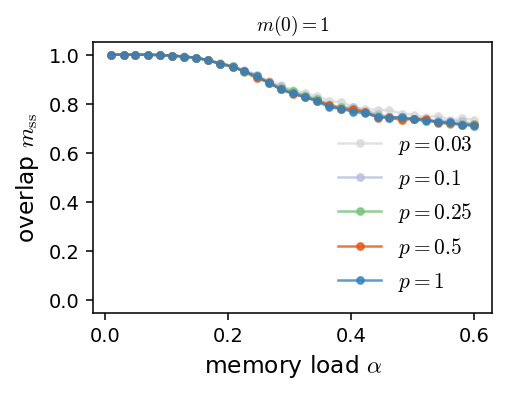

In [5]:
# ============================================================
# Load sparse-W data
# ============================================================

data_path = Path(
    "Scap_sparse_p1_0p5_0p25_0p1_0p03_0_sinf_N1000_g1.5_dt0.2_T10000_ens100_m01.npz"
)

if not data_path.exists():
    raise FileNotFoundError(
        f"{data_path} not found. Check the path and filename."
    )

d = np.load(data_path, allow_pickle=True)

alpha = np.asarray(d["alpha_vals"])
p = np.asarray(d["p_vals"])
overlap_map = np.asarray(d["m_mean"])
overlap_sd = np.asarray(d["m_sd"])
msd_map = np.asarray(d["msd_mean"])
m0 = float(d["init_overlap"])

print(f"file:          {data_path.name}")
print(f"alpha grid:    {len(alpha)} pts, range [{alpha.min():.3g}, {alpha.max():.3g}]")
print(f"p values:      {p}")
print(f"shape:         overlap_map={overlap_map.shape}")
print(f"m0 (init):     {m0:g}")
print(f"overlap range: [{np.nanmin(overlap_map):.3f}, {np.nanmax(overlap_map):.3f}]")
print(f"MSD range:     [{np.nanmin(msd_map):.3f}, {np.nanmax(msd_map):.3f}]")

if np.any(np.isnan(overlap_map)):
    print("WARNING: NaNs present.")


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(3.5, 2.7), constrained_layout=True)

cmap = plt.get_cmap("tab20c_r")

# Color only the nonzero sparse ensembles.
nonzero = np.where(p > 0)[0]
nonzero = nonzero[np.argsort(p[nonzero])]

for k, j in enumerate(nonzero):
    c = cmap(k / max(1, len(nonzero) - 1))

    ax.plot(
        alpha,
        overlap_map[:, j],
        "-o",
        ms=3.5,
        lw=1.3,
        color=c,
        alpha=0.78,
        label=fr"$p = {p[j]:.2g}$",
    )

# W = 0 as a separate control
'''
if np.any(np.isclose(p, 0)):
    j0 = np.where(np.isclose(p, 0))[0][0]

    ax.plot(
        alpha,
        overlap_map[:, j0],
        "--o",
        ms=3.2,
        lw=1.15,
        color="0.45",
        alpha=0.8,
        label=r"$W=0$",
    )
'''

ax.set_xlabel(r"memory load $\alpha$")
ax.set_ylabel(r"overlap $m_{\mathrm{ss}}$")
ax.set_ylim(-0.05, 1.05)

ax.legend(
    frameon=False,
    loc="lower right",
    ncol=1,
)

ax.set_title(rf"$m(0) = {m0:g}$")

plt.show()

In [6]:
fig.savefig(
    "overlap_sparseW.pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)

# High-resolution raster version: useful for preview/submission
fig.savefig(
    "overlap_sparseW.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02,
)

plt.show()